<a href="https://colab.research.google.com/github/anuragsharma2401/Movie-Review-Sentiment-Analysis/blob/main/ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install streamlit pyngrok wordcloud -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 14.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
# import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.naive_bayes import MultinomialNB
from wordcloud import WordCloud

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/IMDB Dataset.csv')
df.shape

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


(50000, 2)

In [ ]:
df['sentiment'].value_counts()

,count
sentiment,
positive,25000
negative,25000


In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)  # remove HTML tags
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)  # remove punctuation
    text = re.sub(r'\n', '', text)  # remove newlines
    return text

df['review'] = df['review'].apply(clean_text)

df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production the filming tech...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically theres a family where a little boy j...,negative
4,petter matteis love in the time of money is a ...,positive


In [ ]:
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,1
1,a wonderful little production the filming tech...,1
2,i thought this was a wonderful way to spend ti...,1
3,basically theres a family where a little boy j...,0
4,petter matteis love in the time of money is a ...,1


In [ ]:
X = df['review']
y = df['sentiment']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (40000,)
Testing size: (10000,)


In [ ]:
vectorizer = TfidfVectorizer(stop_words='english')

X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (40000, 191819)
Testing shape: (10000, 191819)


In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8934


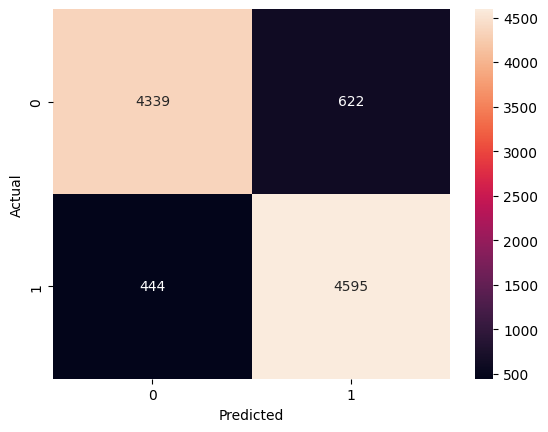

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

nb_accuracy = accuracy_score(y_test, nb_pred)

print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.8672


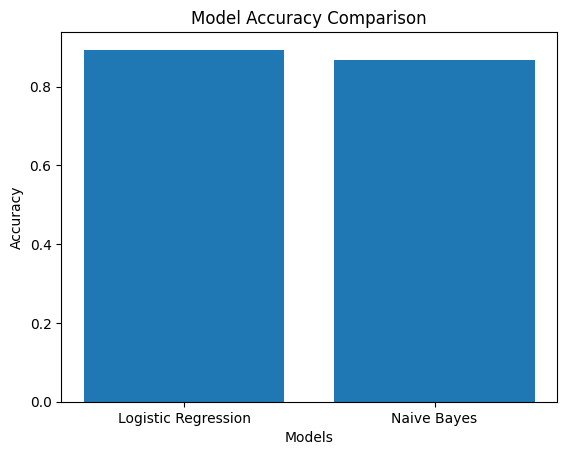

In [ ]:
models = ['Logistic Regression', 'Naive Bayes']
accuracies = [accuracy, nb_accuracy]

import matplotlib.pyplot as plt

plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.show()

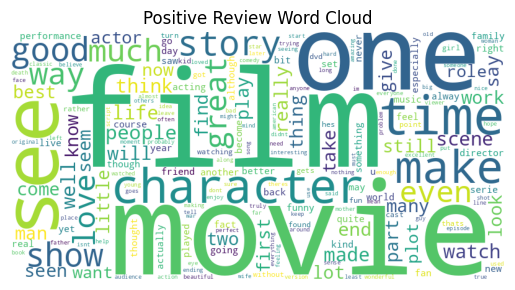

In [ ]:
positive_reviews = df[df['sentiment'] == 1]['review']

text = " ".join(positive_reviews)

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure()
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Positive Review Word Cloud")
plt.show()

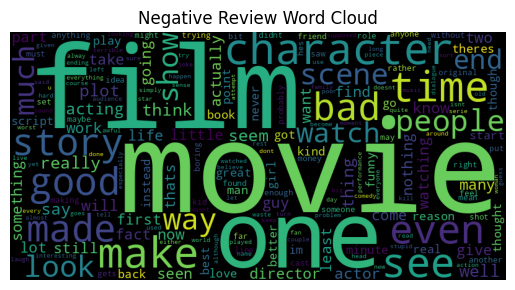

In [ ]:
negative_reviews = df[df['sentiment'] == 0]['review']

text = " ".join(negative_reviews)

wordcloud = WordCloud(width=800, height=400, background_color='black').generate(text)

plt.figure()
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Negative Review Word Cloud")
plt.show()

In [ ]:
import pickle

pickle.dump(model, open('/content/drive/MyDrive/model.pkl', 'wb'))
pickle.dump(vectorizer, open('/content/drive/MyDrive/vectorizer.pkl', 'wb'))

print("✅ Model saved to Drive!")

✅ Model saved to Drive!


In [ ]:
app_code = '''
import streamlit as st
import pickle
import re
import string
import pandas as pd
import matplotlib.pyplot as plt

st.set_page_config(page_title="Movie Sentiment Analyser", page_icon="🎬", layout="centered")

st.markdown("""
<style>
.hero { text-align: center; padding: 2rem 0 1rem; }
.hero h1 { font-size: 3rem; font-weight: 800; background: linear-gradient(90deg, #e50914, #ff6b6b); -webkit-background-clip: text; -webkit-text-fill-color: transparent; }
.hero p { color: #888; font-size: 1.1rem; }
.stTabs [data-baseweb="tab-list"] { gap: 10px; background: #1a1a1a; padding: 8px; border-radius: 12px; }
.stTabs [data-baseweb="tab"] { border-radius: 8px; padding: 8px 20px; color: #aaa; font-weight: 500; }
.stTabs [aria-selected="true"] { background: #e50914 !important; color: white !important; }
textarea { background: #1a1a1a !important; border: 1px solid #333 !important; border-radius: 10px !important; color: white !important; font-size: 1rem !important; }
.stButton > button { background: linear-gradient(90deg, #e50914, #ff6b6b); color: white; border: none; border-radius: 10px; padding: 10px 30px; font-size: 1rem; font-weight: 600; width: 100%; }
.result-box { text-align: center; padding: 2rem; border-radius: 16px; margin-top: 1.5rem; font-size: 1.8rem; font-weight: 700; }
.positive { background: linear-gradient(135deg, #0f2f1a, #1a4a2a); border: 1px solid #2ecc71; color: #2ecc71; }
.negative { background: linear-gradient(135deg, #2f0f0f, #4a1a1a); border: 1px solid #e50914; color: #e50914; }
.metric-card { background: #1a1a1a; border: 1px solid #333; border-radius: 12px; padding: 1.2rem; text-align: center; }
.metric-card h2 { font-size: 2rem; font-weight: 700; margin: 0; }
.metric-card p { color: #888; margin: 0; font-size: 0.9rem; }
footer { visibility: hidden; }
</style>
""", unsafe_allow_html=True)

model = pickle.load(open('/content/drive/MyDrive/model.pkl', 'rb'))
vectorizer = pickle.load(open('/content/drive/MyDrive/vectorizer.pkl', 'rb'))

if 'history' not in st.session_state:
    st.session_state.history = []

def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\\n', '', text)
    return text

st.markdown('<div class="hero"><h1>🎬 Movie Sentiment Analyser</h1><p>Analyse movie reviews instantly using Machine Learning</p></div>', unsafe_allow_html=True)
st.markdown("---")

tab1, tab2, tab3, tab4 = st.tabs(["🎯 Single Review", "📋 Batch Analyzer", "🕓 Review History", "📊 Dashboard"])

with tab1:
    st.markdown("### Enter your movie review")
    review = st.text_area("", placeholder="e.g. This movie was absolutely amazing...", height=150, label_visibility="collapsed")
    if st.button("Analyse Sentiment"):
        if review.strip() == "":
            st.warning("Please enter a review!")
        else:
            cleaned = clean_text(review)
            vectorized = vectorizer.transform([cleaned])
            prediction = model.predict(vectorized)[0]
            proba = model.predict_proba(vectorized)[0]
            confidence = round(max(proba) * 100, 2)
            sentiment = "Positive" if prediction == 1 else "Negative"
            st.session_state.history.append({"Review": review, "Sentiment": sentiment, "Confidence": str(confidence)+"%"})
            if sentiment == "Positive":
                st.markdown('<div class="result-box positive">😊 Positive Sentiment<br><span style="font-size:1rem;font-weight:400;color:#a8e6c1;">Model is ' + str(confidence) + '% confident</span></div>', unsafe_allow_html=True)
            else:
                st.markdown('<div class="result-box negative">😞 Negative Sentiment<br><span style="font-size:1rem;font-weight:400;color:#f5a5a5;">Model is ' + str(confidence) + '% confident</span></div>', unsafe_allow_html=True)
            st.markdown("<br>", unsafe_allow_html=True)
            st.markdown("**Confidence Score: " + str(confidence) + "%**")
            st.progress(int(confidence))
            st.markdown("---")
            st.markdown("### 🔍 Why this prediction?")
            coef = model.coef_[0]
            review_words = cleaned.split()
            word_scores = []
            for word in review_words:
                if word in vectorizer.vocabulary_:
                    idx = vectorizer.vocabulary_[word]
                    score = coef[idx]
                    word_scores.append((word, score))
            if word_scores:
                word_scores = sorted(word_scores, key=lambda x: abs(x[1]), reverse=True)[:10]
                words = [w[0] for w in word_scores]
                scores = [w[1] for w in word_scores]
                colors = ["#2ecc71" if s > 0 else "#e50914" for s in scores]
                fig, ax = plt.subplots(figsize=(8, 4), facecolor="#1a1a1a")
                ax.barh(words, scores, color=colors)
                ax.set_facecolor("#1a1a1a")
                ax.tick_params(colors="white")
                ax.set_xlabel("Impact Score", color="white")
                ax.set_title("Word Impact on Prediction", color="white")
                ax.axvline(x=0, color="white", linewidth=0.8)
                for spine in ax.spines.values():
                    spine.set_edgecolor("#333")
                plt.tight_layout()
                st.pyplot(fig)
            else:
                st.info("No recognizable words found in vocabulary!")

with tab2:
    st.markdown("### Enter multiple reviews (one per line)")
    batch_input = st.text_area("", height=200, placeholder="This movie was great!\\nTerrible film...\\nAbsolutely loved it!", label_visibility="collapsed")
    if st.button("Analyse All"):
        if batch_input.strip() == "":
            st.warning("Please enter at least one review!")
        else:
            reviews = batch_input.strip().split("\\n")
            results = []
            for r in reviews:
                if r.strip():
                    cleaned_r = clean_text(r)
                    vec_r = vectorizer.transform([cleaned_r])
                    pred_r = model.predict(vec_r)[0]
                    sent_r = "Positive" if pred_r == 1 else "Negative"
                    st.session_state.history.append({"Review": r, "Sentiment": sent_r, "Confidence": "N/A"})
                    results.append({"Review": r, "Sentiment": sent_r})
            st.dataframe(pd.DataFrame(results), use_container_width=True)

with tab3:
    st.markdown("### Review History")
    if len(st.session_state.history) == 0:
        st.info("No reviews analysed yet!")
    else:
        st.dataframe(pd.DataFrame(st.session_state.history), use_container_width=True)
        if st.button("Clear History"):
            st.session_state.history = []
            st.success("History cleared!")

with tab4:
    st.markdown("### Sentiment Dashboard")
    if len(st.session_state.history) == 0:
        st.info("No data yet. Analyse some reviews first!")
    else:
        history_df = pd.DataFrame(st.session_state.history)
        counts = history_df["Sentiment"].value_counts()
        total = len(history_df)
        col1, col2, col3 = st.columns(3)
        with col1:
            st.markdown('<div class="metric-card"><h2>' + str(total) + '</h2><p>Total Reviews</p></div>', unsafe_allow_html=True)
        with col2:
            st.markdown('<div class="metric-card"><h2 style="color:#2ecc71">' + str(counts.get("Positive", 0)) + '</h2><p>Positive</p></div>', unsafe_allow_html=True)
        with col3:
            st.markdown('<div class="metric-card"><h2 style="color:#e50914">' + str(counts.get("Negative", 0)) + '</h2><p>Negative</p></div>', unsafe_allow_html=True)
        st.markdown("<br>", unsafe_allow_html=True)
        fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3), facecolor="#1a1a1a")
        ax1.bar(counts.index, counts.values, color=["#2ecc71", "#e50914"])
        ax1.set_facecolor("#1a1a1a")
        ax1.tick_params(colors="white")
        ax1.set_title("Review Counts", color="white")
        ax2.pie(counts.values, labels=counts.index, autopct="%1.1f%%", colors=["#2ecc71", "#e50914"], textprops={"color": "white"})
        ax2.set_title("Sentiment Distribution", color="white")
        plt.tight_layout()
        st.pyplot(fig2)
'''

with open("app.py", "w") as f:
    f.write(app_code)

print("✅ app.py saved!")

✅ app.py saved!


In [ ]:
import subprocess
import time

subprocess.Popen(["streamlit", "run", "app.py",
                  "--server.headless", "true"])
time.sleep(5)
print("✅ Streamlit running!")

✅ Streamlit running!


In [ ]:
from pyngrok import conf, ngrok

# Paste your token here
ngrok.set_auth_token("3BfEmSEz1sMIVsgGVtLGV1aoyfg_3LsjdihWWXKve8Zi4Ztry")

ngrok.kill()
public_url = ngrok.connect(8501)
print("✅ Open this link:", public_url)

ERROR:pyngrok.process.ngrok:t=2026-04-24T08:41:26+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: The authtoken you specified is properly formed, but it is invalid.\nYour authtoken: 3BfEmSEz1sMIVsgGVtLGV1aoyfg_3LsjdihWWXKve8Zi4Ztry\nThis usually happens when:\n    - You reset your authtoken\n    - Your authtoken was for a team account that you were removed from\n    - You are using ngrok link and this credential was explicitly revoked\nGo to your ngrok dashboard and double check that your authtoken is correct:\nhttps://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_107\r\n"
ERROR:pyngrok.process.ngrok:t=2026-04-24T08:41:26+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: The authtoken you specified is properly formed, but it is invalid.\nYour authtoken: 3BfEmSEz1sMIVsgGVtLGV1aoyfg_3LsjdihWWXKve8Zi4Ztry\nThis usually happens when:\n    - You reset your authtoken\n    - Your authtoken was 

PyngrokNgrokError: The ngrok process errored on start: authentication failed: The authtoken you specified is properly formed, but it is invalid.\nYour authtoken: 3BfEmSEz1sMIVsgGVtLGV1aoyfg_3LsjdihWWXKve8Zi4Ztry\nThis usually happens when:\n    - You reset your authtoken\n    - Your authtoken was for a team account that you were removed from\n    - You are using ngrok link and this credential was explicitly revoked\nGo to your ngrok dashboard and double check that your authtoken is correct:\nhttps://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_107\r\n.